Merge Dataframes

In [10]:
import pandas as pd, matplotlib.pyplot as plt
from datasets import load_dataset, Dataset

# Loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()  # Changed: 'to pandas' to 'to_pandas()'

# Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

Example 1
We need to combine two DataFrames:

df_jobs has info similiar to our df DataFrame
df_companies has company info

In [3]:
job_data = {
    'job_id': [1, 2, 3, 4, 5],
    'job_title': ['Data Scientist', 'Software Engineer', 'Product Manager', 'Marketing Director', 'HR Manager'],
    'company_name': ['Google', 'Microsoft', 'Apple', 'Nike', 'Starbucks'],
    'job_location': ['Mountain View, CA', 'Redmond, WA', 'Cupertino, CA', 'Beaverton, OR', 'Seattle, WA']
}

company_data = {
    'company_name': ['Google', 'Microsoft', 'Apple', 'Nike', 'Starbucks'],
    'industry': ['Technology', 'Technology', 'Technology', 'Apparel', 'Food & Beverage'],
    'company_size': ['100,000+', '100,000+', '100,000+', '75,000+', '346,000+']
}


df_jobs = pd.DataFrame(job_data)
df_companies = pd.DataFrame(company_data)

In [ ]:
#example of a simple merge operation
df_jobs.merge(df_companies, on='company_name')

,job_id,job_title,company_name,job_location,industry,company_size
0,1,Data Scientist,Google,"Mountain View, CA",Technology,"100,000+"
1,2,Software Engineer,Microsoft,"Redmond, WA",Technology,"100,000+"
2,3,Product Manager,Apple,"Cupertino, CA",Technology,"100,000+"
3,4,Marketing Director,Nike,"Beaverton, OR",Apparel,"75,000+"
4,5,HR Manager,Starbucks,"Seattle, WA",Food & Beverage,"346,000+"


Example 2

The data we have is only for data science job postings, but what if we wanted to combine insights with other job industries?

Recall the pivot we previously made:

In [12]:
#Bringing back the extracted Russia data frame from the previous example
df_ru = df[df['job_country'] == 'Russia'].copy()
df_ru['job_posted_month'] = df_ru['job_posted_date'].dt.strftime('%B')
df_ru_pivot = df_ru.pivot_table(
    index='job_posted_month', 
    columns='job_title_short', 
    aggfunc='size')
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# Convert month column to categorical with specified order
df_ru_pivot.index = pd.Categorical(
    df_ru_pivot.index, 
    categories=month_order, 
    ordered=True)

# Sort by the categorical order
df_ru_pivot = df_ru_pivot.sort_index()

# Set the index name
df_ru_pivot.index.name = 'job_posted_month'

df_ru_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,5.0,3.0,7.0,198.0,59.0,24.0,3.0,20.0,7.0,27.0
February,2.0,3.0,13.0,141.0,34.0,23.0,3.0,16.0,10.0,27.0
March,4.0,2.0,15.0,119.0,38.0,25.0,2.0,13.0,5.0,12.0
April,9.0,1.0,24.0,160.0,61.0,19.0,4.0,21.0,6.0,26.0
May,1.0,NaN,15.0,126.0,25.0,17.0,1.0,9.0,6.0,18.0
June,7.0,1.0,10.0,131.0,55.0,21.0,NaN,12.0,8.0,21.0
July,17.0,6.0,15.0,161.0,58.0,30.0,NaN,13.0,13.0,34.0
August,31.0,4.0,21.0,153.0,76.0,30.0,7.0,20.0,14.0,49.0
September,29.0,4.0,29.0,180.0,65.0,31.0,3.0,19.0,9.0,40.0


In [11]:
#import data, but call it Russia figures (fictitious)
df_ru_software_pivot = pd.read_csv('https://lukeb.co/software_csv', index_col='job_posted_month')
df_ru_software_pivot

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
January,13619,9827,5108,4348
February,11456,9116,7298,4284
March,11102,8178,5814,4159
April,14037,9209,7232,4220
May,12126,8864,6718,4980
June,12003,8065,5902,4781
July,11914,8061,6839,4344
August,11571,8191,7413,4104
September,14016,8447,6139,4094


In [13]:
#we can combine these using merge:
df_ru_merged = df_ru_pivot.merge(df_ru_software_pivot, on='job_posted_month')
df_ru_merged

,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,,,,,,,,,,,
January,5.0,3.0,7.0,198.0,59.0,24.0,3.0,20.0,7.0,27.0,13619,9827,5108,4348
February,2.0,3.0,13.0,141.0,34.0,23.0,3.0,16.0,10.0,27.0,11456,9116,7298,4284
March,4.0,2.0,15.0,119.0,38.0,25.0,2.0,13.0,5.0,12.0,11102,8178,5814,4159
April,9.0,1.0,24.0,160.0,61.0,19.0,4.0,21.0,6.0,26.0,14037,9209,7232,4220
May,1.0,NaN,15.0,126.0,25.0,17.0,1.0,9.0,6.0,18.0,12126,8864,6718,4980
June,7.0,1.0,10.0,131.0,55.0,21.0,NaN,12.0,8.0,21.0,12003,8065,5902,4781
July,17.0,6.0,15.0,161.0,58.0,30.0,NaN,13.0,13.0,34.0,11914,8061,6839,4344
August,31.0,4.0,21.0,153.0,76.0,30.0,7.0,20.0,14.0,49.0,11571,8191,7413,4104
September,29.0,4.0,29.0,180.0,65.0,31.0,3.0,19.0,9.0,40.0,14016,8447,6139,4094


Now we can plot the merged dataframe
We will plot the bottom five jobs 

In [30]:
bottom_5  = (df_ru_merged
             .sum()
             .sort_values(ascending=True)
             .head(5)
             .index
             .to_list()
             ) #gets only the index/ name
bottom_5

['Cloud Engineer',
 'Senior Data Analyst',
 'Senior Data Scientist',
 'Business Analyst',
 'Senior Data Engineer']

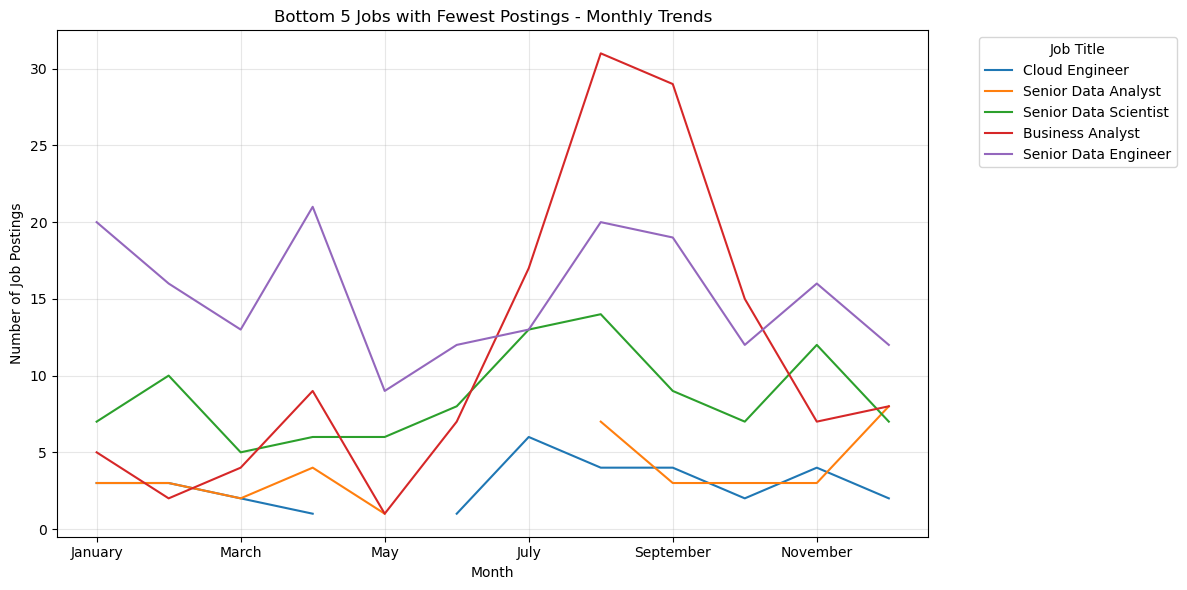

In [38]:
df_ru_merged[bottom_5].plot(kind='line', figsize=(12, 6))
plt.title('Bottom 5 Jobs with Fewest Postings - Monthly Trends')
plt.xlabel('Month')
plt.ylabel('Number of Job Postings')
plt.legend(title='Job Title', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

We can also plot the merged dataframe
We will plot the top five jobs 

In [35]:
top_5  = (df_ru_merged
             .sum()
             .sort_values(ascending=False)
             .head(5)
             .index
             .to_list()
             ) #gets only the index/ name
top_5

['Front-End Developer',
 'Back-End Developer',
 'Full-Stack Developer',
 'UI/UX Designer',
 'Data Engineer']

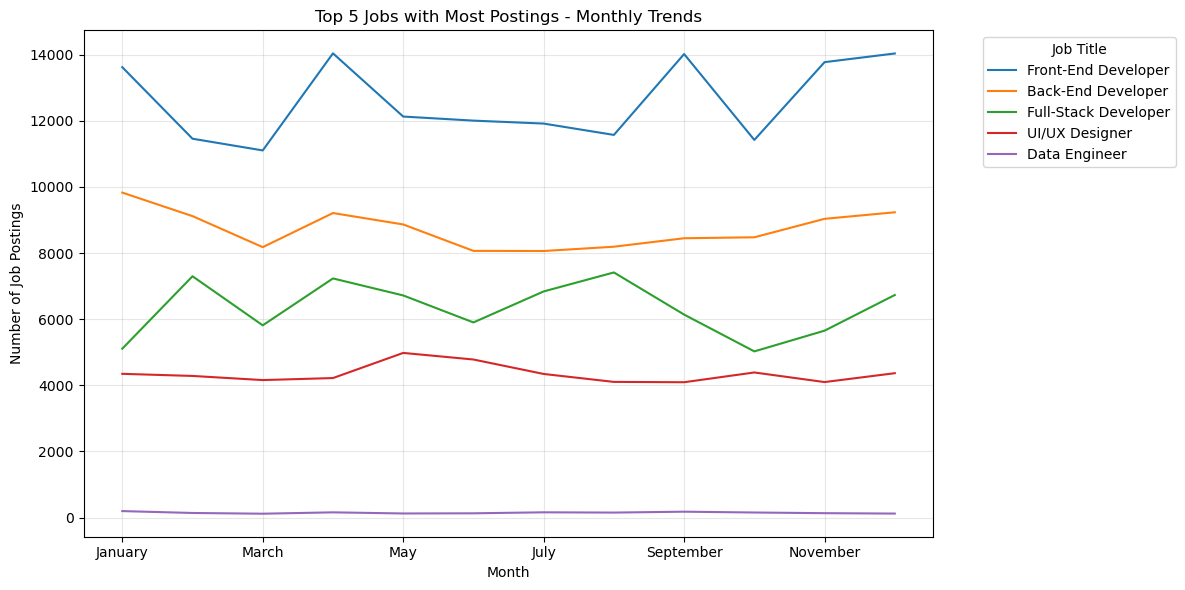

In [39]:
df_ru_merged[top_5].plot(kind='line', figsize=(12, 6))
plt.title('Top 5 Jobs with Most Postings - Monthly Trends')
plt.xlabel('Month')
plt.ylabel('Number of Job Postings')
plt.legend(title='Job Title', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()